# Notebook for handling the simulation

In [2]:
# Import stuff
from src.lattice import SpinLattice
from src.hamiltonian import Hamiltonian
from src.solver import RungeKutta4Solver
from src.io_handler import IOHandler
from src.visualizer import Visualizer
from src.analyzer import LatticeAnalyzer

import numpy as np
import cupy as cp

In [3]:
# Set simulation parameters
Lx, Ly = 128,128
total_steps = 10000
dt = 0.01
save_interval = 2000

J = 1.0
DMI = 0.08
dmi_type = 'if'
B = 0.02
alpha = 0.05

In [4]:
# Initialize Modules
lattice = SpinLattice(Lx, Ly)
lattice.initialize_ferromagnetic()

# customize lattice
custom_spins = np.zeros((Lx, Ly, 3))
custom_spins[:,:,2] = 1
custom_spins[50:60, 50:60, 2] = -1

# set lattice to customized lattice
lattice.set_custom_state(custom_spins)

# Initialize the other modules
hamiltonian = Hamiltonian(J=J, D=DMI, dmi_type=dmi_type, 
                            B=B, alpha=alpha)
solver = RungeKutta4Solver(lattice, hamiltonian)
io_handler = IOHandler(output_dir="output")

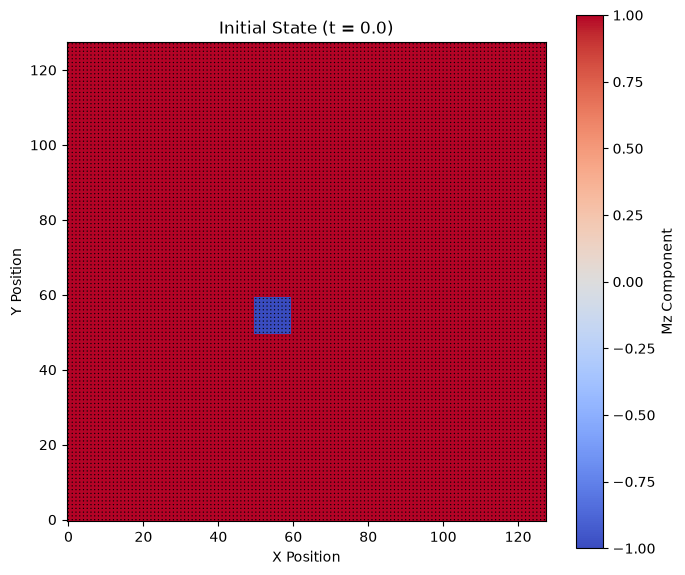

In [5]:
# 3. Visualize Initial State
lattice_spins_cpu = cp.asnumpy(lattice.spins)
Visualizer.plot_vector_field(lattice_spins_cpu, title="Initial State (t = 0.0)")

In [6]:
# Simulation Loop
t = 0.0
for step in range(1, total_steps + 1):
    # Perform time integration step
    lattice.spins = solver.step(t, lattice.spins, dt)
    t += dt

    # Periodically save checkpoints
    if step % save_interval == 0:
        print(f"Step {step}/{total_steps}, Time: {t:.2f}")
        lattice_spins_cpu = cp.asnumpy(lattice.spins)
        io_handler.save_checkpoint(step, t, lattice_spins_cpu)

Step 2000/10000, Time: 20.00
Checkpoint saved: output\checkpoint_step_02000.npz
Step 4000/10000, Time: 40.00
Checkpoint saved: output\checkpoint_step_04000.npz
Step 6000/10000, Time: 60.00
Checkpoint saved: output\checkpoint_step_06000.npz
Step 8000/10000, Time: 80.00
Checkpoint saved: output\checkpoint_step_08000.npz
Step 10000/10000, Time: 100.00
Checkpoint saved: output\checkpoint_step_10000.npz


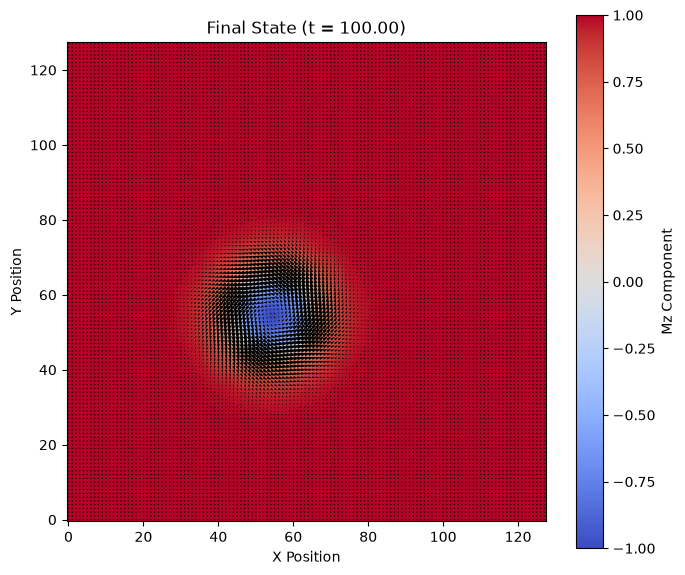

In [7]:
# Visualize Final State
lattice_spins_cpu = cp.asnumpy(lattice.spins)
Visualizer.plot_vector_field(lattice_spins_cpu, title=f"Final State (t = {t:.2f})")

Total topological charge Q = -0.9924458139612059


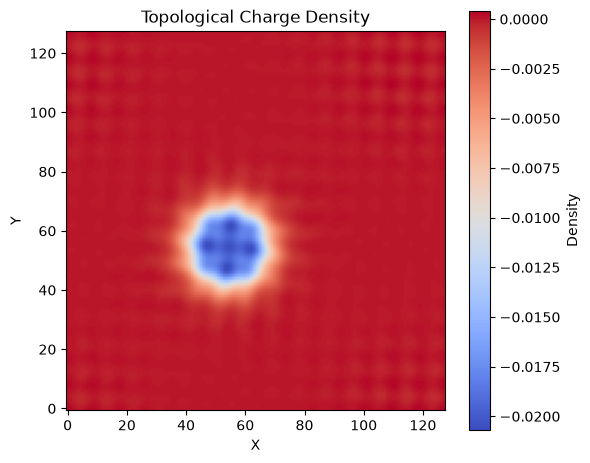

In [8]:
# Calculate and visualiz topological charge density
analyzer = LatticeAnalyzer(spins=lattice.spins)
charge_density = analyzer.compute_topological_charge_density()
total_top_charge = analyzer.compute_total_topological_charge()
print(f'Total topological charge Q = {total_top_charge}')
Visualizer.plot_scalar_field( field=cp.asnumpy(charge_density) )